this work is on sub sample dataset not full dataset 


STEP 1 — Install All Required Libraries

In [12]:
import sys
import subprocess

packages = [
    'tensorflow',
    'opencv-python',
    'numpy',
    'pandas',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'tqdm',
    'Pillow',
    'ipywidgets',
    'ipython',
]


for pkg in packages:
    print(f'    Installing {pkg}...', end=' ')
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '--quiet', '--upgrade'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print('')
    else:
        print(f'  Error: {result.stderr[:100]}')



    Installing tensorflow... 
    Installing opencv-python... 
    Installing numpy... 
    Installing pandas... 
    Installing matplotlib... 
    Installing seaborn... 
    Installing scikit-learn... 
    Installing tqdm... 
    Installing Pillow... 
    Installing ipywidgets... 
    Installing ipython... 


 Paths, Classes 

In [14]:
import os
import numpy as np

#     PATHS

DATASET_PATH      = r'D:\AI FOR SOCIAL GOOD 1\Dataset'
SAVE_DIR          = r'D:\AI FOR SOCIAL GOOD 1\processed_data'
MODEL_SAVE_PATH   = r'D:\AI FOR SOCIAL GOOD 1\surveillance_model.keras'
LOG_DIR           = r'D:\AI FOR SOCIAL GOOD 1\logs'

CLASS_NAMES = [
    'Abuse',
    'Arrest',
    'Arson',
    'Assault',
    'Burglary',
    'Explosion',
    'Fighting',
    'Normal',
    'RoadAccidents',
    'Robbery',
    'Shooting',
    'Shoplifting',
    'Stealing',
    'Vandalism',
]
# 1 - safe -------------------------------  10  means risky
SEVERITY_MAP = {
    'Normal':        1,
    'Shoplifting':   3,
    'Stealing':      4,
    'Vandalism':     4,
    'Burglary':      5,
    'RoadAccidents': 6,
    'Arrest':        6,
    'Abuse':         7,
    'Robbery':       7,
    'Fighting':      7,
    'Assault':       8,
    'Arson':         9,
    'Explosion':     10,
    'Shooting':      10,
}


In [ ]:

FRAMES_PER_VIDEO  = 16     
IMAGE_HEIGHT      = 112    
IMAGE_WIDTH       = 112    
CHANNELS          = 3     

BATCH_SIZE        = 8      
EPOCHS            = 30
LEARNING_RATE     = 1e-4
VALIDATION_SPLIT  = 0.15
TEST_SPLIT        = 0.10
NUM_CLASSES       = len(CLASS_NAMES)
SEED              = 42
np.random.seed(SEED)

for folder in [SAVE_DIR, LOG_DIR]:
    os.makedirs(folder, exist_ok=True)


In [15]:


print(f'  Dataset path     : {DATASET_PATH}')
print(f'  Preprocessed to  : {SAVE_DIR}')
print(f'  Model saved to   : {MODEL_SAVE_PATH}')
print(f'  Classes          : {NUM_CLASSES}')
print(f'  Frames/video     : {FRAMES_PER_VIDEO}')
print(f'  Frame size       : {IMAGE_HEIGHT}×{IMAGE_WIDTH}')
print(f'  Batch size       : {BATCH_SIZE}')
print(f'  Epochs           : {EPOCHS}')

if os.path.exists(DATASET_PATH):
    folders = [f for f in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, f))]
    print(f'\n Dataset found! Detected {len(folders)} class folders:')


  Dataset path     : D:\AI FOR SOCIAL GOOD 1\Dataset
  Preprocessed to  : D:\AI FOR SOCIAL GOOD 1\processed_data
  Model saved to   : D:\AI FOR SOCIAL GOOD 1\surveillance_model.keras
  Classes          : 14
  Frames/video     : 16
  Frame size       : 112×112
  Batch size       : 8
  Epochs           : 30

 Dataset found! Detected 14 class folders:


 Preprocess Videos (Frame Extraction & Subsampling)


In [16]:
import cv2
import numpy as np
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# function for froame extraction
def extract_frames(video_path, n_frames=FRAMES_PER_VIDEO,
                   height=IMAGE_HEIGHT, width=IMAGE_WIDTH):
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        cap.release()
        return None

    indices = np.linspace(0, total_frames - 1, n_frames, dtype=int)

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((height, width, 3), dtype=np.uint8)
        else:
            frame = cv2.resize(frame, (width, height))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()

    while len(frames) < n_frames:
        frames.append(np.zeros((height, width, 3), dtype=np.uint8))

    return np.array(frames, dtype=np.float32) / 255.0   



In [18]:

print(' Starting video preprocessing...\n')
print(f'   Extracting {FRAMES_PER_VIDEO} frames per video at {IMAGE_HEIGHT}×{IMAGE_WIDTH}\n')

all_sequences = []  
all_labels    = []  
all_paths     = []  
skipped       = 0


 Starting video preprocessing...

   Extracting 16 frames per video at 112×112



In [19]:

VIDEO_EXTENSIONS = ('.mp4', '.avi', '.mov', '.mkv', '.wmv', '.flv', '.mpeg', '.mpg')

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_folder = os.path.join(DATASET_PATH, class_name)

    if not os.path.exists(class_folder):
        available = os.listdir(DATASET_PATH)
        match = next((f for f in available if f.lower() == class_name.lower()), None)
        if match:
            class_folder = os.path.join(DATASET_PATH, match)
        else:
            print(f'    Folder not found: {class_name} → skipping')
            continue

    videos = [
        f for f in os.listdir(class_folder)
        if f.lower().endswith(VIDEO_EXTENSIONS)
    ]

    print(f'   [{class_idx+1:>2}/{NUM_CLASSES}] {class_name:<18} → {len(videos)} videos found')

    for video_file in tqdm(videos, desc=f'      Processing', leave=False, ncols=70):
        video_path = os.path.join(class_folder, video_file)
        frames = extract_frames(video_path)

        if frames is None:
            skipped += 1
            continue

        all_sequences.append(frames)
        all_labels.append(class_idx)
        all_paths.append(video_path)


   [ 1/14] Abuse              → 50 videos found


   [ 2/14] Arrest             → 50 videos found


   [ 3/14] Arson              → 50 videos found


   [ 4/14] Assault            → 50 videos found


   [ 5/14] Burglary           → 100 videos found


...

   [ 8/14] Normal             → 60 videos found


    Folder not found: RoadAccidents → skipping
   [10/14] Robbery            → 150 videos found


   [11/14] Shooting           → 50 videos found


    Folder not found: Shoplifting → skipping
   [13/14] Stealing           → 100 videos found


   [14/14] Vandalism          → 50 videos found


 Train/Val/Test Split
Then we split into Train (75%) / Validation (15%) / Test (10%) sets.

In [20]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split

print(' Converting to NumPy arrays...')
X = np.array(all_sequences, dtype=np.float32)   
y = np.array(all_labels,    dtype=np.int32)      

print(f'   X shape (videos): {X.shape}')
print(f'   y shape (labels): {y.shape}')

print('\n Class Distribution:')
print('   Class                    Count')
print('   ' + '-'*35)
unique, counts = np.unique(y, return_counts=True)
for idx, cnt in zip(unique, counts):
    bar = '' * (cnt // max(1, max(counts) // 20))
    print(f'   {CLASS_NAMES[idx]:<22} {cnt:>4}  {bar}')

print('\n Splitting dataset...')

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=TEST_SPLIT,
    stratify=y,
    random_state=SEED
)

val_ratio = VALIDATION_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_ratio,
    stratify=y_trainval,
    random_state=SEED
)

print(f'   Train set : {X_train.shape[0]} videos')
print(f'   Val   set : {X_val.shape[0]} videos')
print(f'   Test  set : {X_test.shape[0]} videos')

print('\n Saving preprocessed arrays to disk...')

np.save(os.path.join(SAVE_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(SAVE_DIR, 'X_val.npy'),   X_val)
np.save(os.path.join(SAVE_DIR, 'X_test.npy'),  X_test)
np.save(os.path.join(SAVE_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(SAVE_DIR, 'y_val.npy'),   y_val)
np.save(os.path.join(SAVE_DIR, 'y_test.npy'),  y_test)

# Save class names list
np.save(os.path.join(SAVE_DIR, 'class_names.npy'), np.array(CLASS_NAMES))

print(f'\n All data saved to: {SAVE_DIR}')
print('     Next time you can skip Steps 4–5 and load directly from disk!')

 Converting to NumPy arrays...
   X shape (videos): (810, 16, 112, 112, 3)
   y shape (labels): (810,)

 Class Distribution:
   Class                    Count
   -----------------------------------
   Abuse                    50  
   Arrest                   50  
   Arson                    50  
   Assault                  50  
   Burglary                100  
   Explosion                50  
   Fighting                 50  
   Normal                   60  
   Robbery                 150  
   Shooting                 50  
   Stealing                100  
   Vandalism                50  

 Splitting dataset...
   Train set : 607 videos
   Val   set : 122 videos
   Test  set : 81 videos

 Saving preprocessed arrays to disk...

 All data saved to: D:\AI FOR SOCIAL GOOD 1\processed_data
     Next time you can skip Steps 4–5 and load directly from disk!


In [22]:

print(f'\n Preprocessing complete!')
print(f'   Total videos processed : {len(all_sequences)}')
print(f'   Videos skipped (error) : {skipped}')
print(f'   Data shape per video   : {all_sequences[0].shape if all_sequences else "N/A"}')


 Preprocessing complete!
   Total videos processed : 810
   Videos skipped (error) : 0
   Data shape per video   : (16, 112, 112, 3)


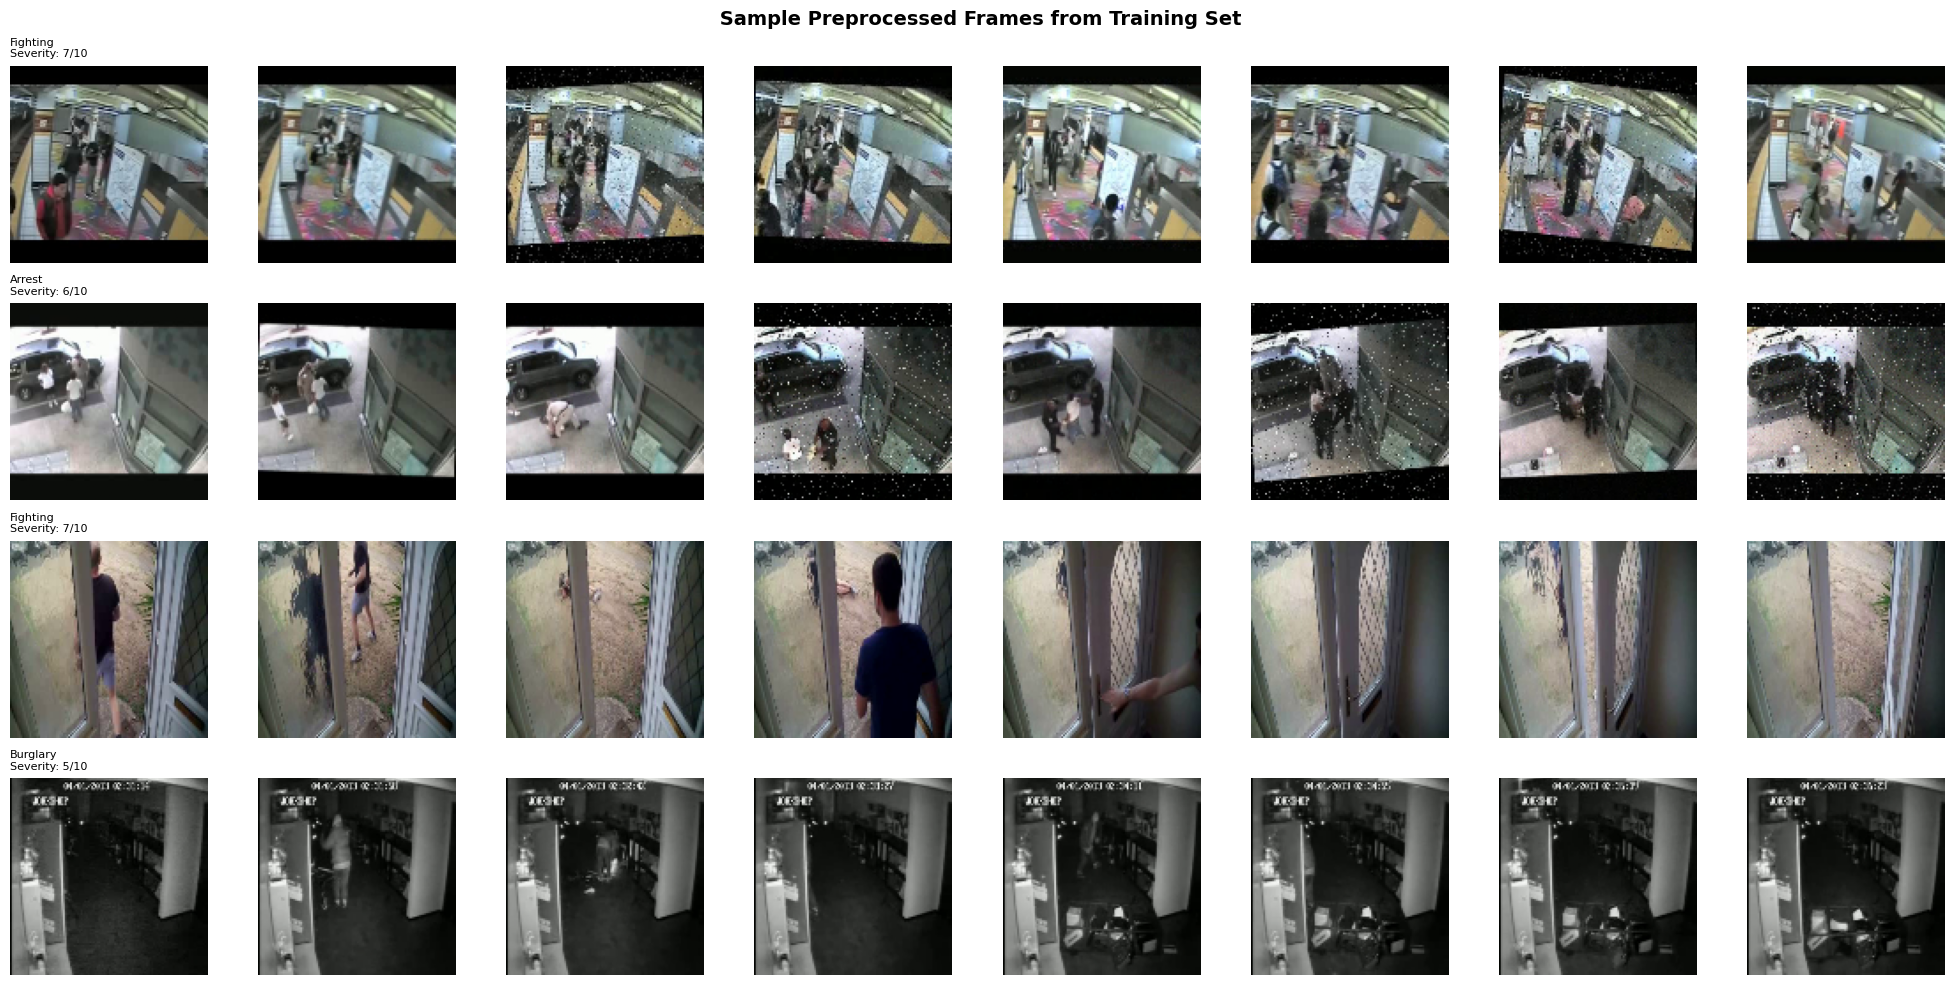

In [23]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle(' Sample Preprocessed Frames from Training Set', fontsize=14, fontweight='bold')

sampled_indices = np.random.choice(len(X_train), size=4, replace=False)

for row, vid_idx in enumerate(sampled_indices):
    class_name = CLASS_NAMES[y_train[vid_idx]]
    severity   = SEVERITY_MAP[class_name]

    for col in range(8):
        ax = axes[row, col]
        frame = X_train[vid_idx, col * 2]   
        ax.imshow(np.clip(frame, 0, 1))
        ax.axis('off')
        if col == 0:
            ax.set_title(f'{class_name}\nSeverity: {severity}/10',
                         fontsize=8, ha='left', x=0)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'sample_frames.png'), dpi=100, bbox_inches='tight')
plt.show()



**Architecture: CNN Backbone + LSTM for Temporal Understanding**

```
Input Video (16 frames)
       ↓
MobileNetV2 (pretrained on ImageNet) — extracts features from each frame
       ↓
TimeDistributed wrapper — applies CNN to each frame independently
       ↓
LSTM Layer — learns patterns across time (temporal sequence)
       ↓
Dense + Dropout — reduces overfitting
       ↓
Softmax Output — 14 class probabilities
```

In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint,
    ReduceLROnPlateau, TensorBoard
)

In [ ]:

import os

def build_surveillance_model(num_classes, frames, height, width, channels):
    #CNN + LSTM Video Classification Model.
    #MobileNetV2 extracts spatial features → LSTM captures temporal patterns.

    inputs = layers.Input(shape=(frames, height, width, channels),
                          name='video_input')

    # ── CNN  (MobileNetV2, pretrained, feature extractor only) 
    backbone = MobileNetV2(
        input_shape=(height, width, channels),
        include_top=False,
        weights='imagenet',    # Use pretrained ImageNet weights
        pooling='avg'          # Global average pooling → flat feature vector
    )
    # Freeze backbone for faster training (we fine-tune later)
    backbone.trainable = False

    # Output shape: (batch, frames, 1280)
    x = layers.TimeDistributed(backbone, name='frame_features')(inputs)

    # Self-attention over the frame sequence
    attention = layers.Dense(1, activation='tanh', name='attention_score')(x)
    attention = layers.Flatten()(attention)
    attention = layers.Activation('softmax', name='attention_weights')(attention)
    attention = layers.RepeatVector(1280)(attention)
    attention = layers.Permute([2, 1])(attention)
    attended  = layers.Multiply()([x, attention])

    # ── LSTM: Learn temporal sequence patterns ──
    x = layers.LSTM(256, return_sequences=True,  name='lstm_1')(attended)
    x = layers.LSTM(128, return_sequences=False, name='lstm_2')(x)

    # ── Classifier Head ──
    x = layers.Dense(256, activation='relu', name='dense_1')(x)
    x = layers.Dropout(0.4, name='dropout_1')(x)
    x = layers.Dense(128, activation='relu', name='dense_2')(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)

    # ── Output: 14 class probabilities ──
    outputs = layers.Dense(num_classes, activation='softmax', name='classification')(x)

    model = Model(inputs=inputs, outputs=outputs, name='SurveillanceAI')
    return model


In [26]:


#  Create  model
model = build_surveillance_model(
    num_classes=NUM_CLASSES,
    frames=FRAMES_PER_VIDEO,
    height=IMAGE_HEIGHT,
    width=IMAGE_WIDTH,
    channels=CHANNELS
)

# Compile 
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [27]:

print(' MODEL ARCHITECTURE SUMMARY')
model.summary()
total_params = model.count_params()
print(f'\n Model built successfully!')
print(f'   Total parameters   : {total_params:,}')
print(f'   Trainable params   : {sum(tf.size(w).numpy() for w in model.trainable_weights):,}')
print(f'   Input shape        : {model.input_shape}')
print(f'   Output shape       : {model.output_shape}')

 MODEL ARCHITECTURE SUMMARY


Model: "SurveillanceAI"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ video_input         │ (None, 16, 112,   │          0 │ -                 │
│ (InputLayer)        │ 112, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ frame_features      │ (None, 16, 1280)  │  2,257,984 │ video_input[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_score     │ (None, 16, 1)     │      1,281 │ frame_features[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16)        │          0 │ attention_score[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 16)        │          0 │ flatten_1[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 1280, 16)  │          0 │ attention_weight… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_1 (Permute) │ (None, 16, 1280)  │          0 │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 16, 1280)  │          0 │ frame_features[0… │
│ (Multiply)          │                   │            │ permute_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 16, 256)   │  1,573,888 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 128)       │    197,120 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     33,024 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 14)        │      1,806 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,097,999 (15.63 MB)

 Trainable params: 1,840,015 (7.02 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


 Model built successfully!
   Total parameters   : 4,097,999
   Trainable params   : 1,840,015
   Input shape        : (None, 16, 112, 112, 3)
   Output shape       : (None, 14)



 — Train the Model


In [28]:
!pip install tensorboard
import tensorflow as tf
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint,
    ReduceLROnPlateau, TensorBoard
)

In [29]:

from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os


In [30]:

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

In [31]:

class_weights = dict(enumerate(class_weights_array))
print('  Class weights (handles imbalance):')
for idx, w in class_weights.items():
    print(f'   {CLASS_NAMES[idx]:<22} weight = {w:.3f}')


  Class weights (handles imbalance):
   Abuse                  weight = 1.331
   Arrest                 weight = 1.331
   Arson                  weight = 1.367
   Assault                weight = 1.367
   Burglary               weight = 0.674
   Explosion              weight = 1.367
   Fighting               weight = 1.331
   Normal                 weight = 1.124
   RoadAccidents          weight = 0.452
   Robbery                weight = 1.367
   Shooting               weight = 0.674
   Shoplifting            weight = 1.331


In [32]:

# Callbacks
callbacks = [

    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    # Save the best model automatically
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # Reduce learning rate when stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    # TensorBoard logs for visualization
    TensorBoard(
        log_dir=LOG_DIR,
        histogram_freq=1
    ),
]


In [34]:

class_weights = dict(enumerate(class_weights_array))
print('⚖️  Class weights (handles imbalance):')
for idx, w in class_weights.items():
    print(f'   {CLASS_NAMES[idx]:<22} weight = {w:.3f}')

# Callbacks
callbacks = [

    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    # Save the best model automatically
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # Reduce learning rate when stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    # TensorBoard logs for visualization
    TensorBoard(
        log_dir=LOG_DIR,
        histogram_freq=1
    ),
]

print('\n PHASE 1: Training classifier head (backbone frozen)...')
print('   This is fast because we only train the top layers.\n')

history_phase1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

#  Fine-tune 
backbone_layer = model.get_layer('time_distributed').layer
backbone_layer.trainable = True
for layer in backbone_layer.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE / 10),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)



⚖️  Class weights (handles imbalance):
   Abuse                  weight = 1.331
   Arrest                 weight = 1.331
   Arson                  weight = 1.367
   Assault                weight = 1.367
   Burglary               weight = 0.674
   Explosion              weight = 1.367
   Fighting               weight = 1.331
   Normal                 weight = 1.124
   RoadAccidents          weight = 0.452
   Robbery                weight = 1.367
   Shooting               weight = 0.674
   Shoplifting            weight = 1.331

 PHASE 1: Training classifier head (backbone frozen)...
   This is fast because we only train the top layers.

Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.0973 - loss: 2.9745
Epoch 1: val_accuracy improved from None to 0.18852, saving model to D:\AI FOR SOCIAL GOOD 1\surveillance_model.keras

Epoch 1: finished saving model to D:\AI FOR SOCIAL GOOD 1\surveillance_model.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.1170 - loss: 2.

ValueError: No such layer: time_distributed. Existing layers are: ['video_input', 'frame_features', 'attention_score', 'flatten_1', 'attention_weights', 'repeat_vector_1', 'permute_1', 'multiply_1', 'lstm_1', 'lstm_2', 'dense_1', 'dropout_1', 'dense_2', 'dropout_2', 'classification'].

In [35]:

print('\n PHASE 1: Training classifier head (backbone frozen)...')
print('   This is fast because we only train the top layers.\n')



 PHASE 1: Training classifier head (backbone frozen)...
   This is fast because we only train the top layers.



In [36]:

history_phase1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.4134 - loss: 2.0449
Epoch 1: val_accuracy did not improve from 0.28689
76/76 ━━━━━━━━━━━━━━━━━━━━ 46s 602ms/step - accuracy: 0.3987 - loss: 2.0627 - val_accuracy: 0.2623 - val_loss: 2.3323 - learning_rate: 5.0000e-05
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.4353 - loss: 1.9801
Epoch 2: val_accuracy improved from 0.28689 to 0.30328, saving model to D:\AI FOR SOCIAL GOOD 1\surveillance_model.keras

Epoch 2: finished saving model to D:\AI FOR SOCIAL GOOD 1\surveillance_model.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 43s 570ms/step - accuracy: 0.4432 - loss: 1.9372 - val_accuracy: 0.3033 - val_loss: 2.3235 - learning_rate: 5.0000e-05
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.4726 - loss: 1.8623
Epoch 3: val_accuracy did not improve from 0.30328

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
76/76 ━━━━━━━━━━━━━━━━━━━━ 45s 590ms/step - accuracy: 0.4712 - los

In [37]:

#  Fine-tune 
backbone_layer = model.get_layer('time_distributed').layer
backbone_layer.trainable = True
for layer in backbone_layer.layers[:-20]:
    layer.trainable = False


ValueError: No such layer: time_distributed. Existing layers are: ['video_input', 'frame_features', 'attention_score', 'flatten_1', 'attention_weights', 'repeat_vector_1', 'permute_1', 'multiply_1', 'lstm_1', 'lstm_2', 'dense_1', 'dropout_1', 'dense_2', 'dropout_2', 'classification'].

In [ ]:

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE / 10),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:

history_phase2 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)



 STEP 8 — Evaluate & Visualize Results


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

In [ ]:

import os

print(' Evaluating on Test Set...')
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0, batch_size=BATCH_SIZE)
print(f'\n   Test Accuracy : {test_acc * 100:.2f}%')
print(f'   Test Loss     : {test_loss:.4f}')


In [ ]:

def combine_history(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])


In [ ]:

train_acc  = combine_history(history_phase1, history_phase2, 'accuracy')
val_acc    = combine_history(history_phase1, history_phase2, 'val_accuracy')
train_loss = combine_history(history_phase1, history_phase2, 'loss')
val_loss   = combine_history(history_phase1, history_phase2, 'val_loss')


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(' Training History', fontsize=14, fontweight='bold')


In [ ]:

# Accuracy
axes[0].plot(train_acc, label='Train Accuracy', color='#2196F3', linewidth=2)
axes[0].plot(val_acc,   label='Val Accuracy',   color='#FF5722', linewidth=2)
axes[0].axhline(y=test_acc, color='green', linestyle='--', label=f'Test Acc: {test_acc:.2%}')
axes[0].set_title('Accuracy Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

In [ ]:


# Loss
axes[1].plot(train_loss, label='Train Loss', color='#2196F3', linewidth=2)
axes[1].plot(val_loss,   label='Val Loss',   color='#FF5722', linewidth=2)
axes[1].set_title('Loss Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_history.png'), dpi=100, bbox_inches='tight')
plt.show()


In [ ]:

# 3. Confusion Matrix
print('\n Generating Confusion Matrix...')
y_pred_probs = model.predict(X_test, verbose=0, batch_size=BATCH_SIZE)
y_pred       = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)

In [ ]:

ax.set_title(' Confusion Matrix — Test Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=100, bbox_inches='tight')
plt.show()

print('\n DETAILED CLASSIFICATION REPORT')
print('─' * 65)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))
print(f'\n Final Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')

Scoring System (1–10 Scale)
 score from 1 (normal) to 10 (most dangerous). 


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


In [ ]:

def predict_with_severity(video_frames, model, class_names, severity_map):
    
    # Add batch dimension: (1, frames, H, W, C)
    x = np.expand_dims(video_frames, axis=0)

    # Get model predictions
    probs = model.predict(x, verbose=0)[0]
    pred_idx    = np.argmax(probs)
    confidence  = float(probs[pred_idx])
    pred_class  = class_names[pred_idx]

    base_severity = severity_map[pred_class]

    adjusted_severity = confidence * base_severity + (1 - confidence) * 5.0
    adjusted_severity = round(min(10.0, max(1.0, adjusted_severity)), 1)

    # Top-3 predictions for interpretability
    top3_idx  = np.argsort(probs)[::-1][:3]
    top3 = [(class_names[i], round(float(probs[i]) * 100, 1)) for i in top3_idx]

    return {
        'predicted_class': pred_class,
        'confidence':      round(confidence * 100, 1),
        'severity_score':  adjusted_severity,
        'base_severity':   base_severity,
        'top3_predictions': top3,
        'alert_level':     get_alert_level(adjusted_severity),
        'action_required': get_action(adjusted_severity)
    }



In [ ]:

def get_alert_level(score):
    if score <= 2:  return ' NORMAL'
    elif score <= 4: return ' LOW'
    elif score <= 6: return ' MEDIUM'
    elif score <= 8: return ' HIGH'
    else:            return ' CRITICAL'



In [ ]:

def get_action(score):
    if score <= 2:  return 'No action required — routine activity'
    elif score <= 4: return 'Log and monitor — minor incident'
    elif score <= 6: return 'Dispatch nearest security officer'
    elif score <= 8: return 'IMMEDIATE response needed — notify supervisor'
    else:            return 'EMERGENCY — alert police + lock down area'


print(' SEVERITY SCORING SYSTEM — DEMO')


In [ ]:

sample_indices = np.random.choice(len(X_test), size=8, replace=False)

for i, idx in enumerate(sample_indices):
    result      = predict_with_severity(X_test[idx], model, CLASS_NAMES, SEVERITY_MAP)
    true_class  = CLASS_NAMES[y_test[idx]]

    print(f'\n  Sample {i+1}: {correct_icon} True={true_class}')
    print(f'    Predicted    : {result["predicted_class"]} ({result["confidence"]}% confidence)')
    print(f'    Severity     : {result["severity_score"]}/10  →  {result["alert_level"]}')
    print(f'    Action       : {result["action_required"]}')
    print(f'    Top-3 options: ', end='')
    print(', '.join([f"{c}({p}%)" for c, p in result['top3_predictions']]))


 classification + severity alert.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import time



In [ ]:

def analyze_cctv_video(video_path, model, class_names, severity_map,
                        frames_per_video=FRAMES_PER_VIDEO,
                        height=IMAGE_HEIGHT, width=IMAGE_WIDTH):
    

    # Step 1: Extract frames
    frames = extract_frames(video_path, n_frames=frames_per_video,
                            height=height, width=width)
    if frames is None:
        print(' Could not read video!')
        return None

    # Step 2: Predict
    result = predict_with_severity(frames, model, class_names, severity_map)
    elapsed = time.time() - t0
    print(f'Done in {elapsed:.2f}s')

    # Step 3: Severity color
    score = result['severity_score']
    if   score <= 2: color = '#4CAF50'   # Green
    elif score <= 4: color = '#FFEB3B'   # Yellow
    elif score <= 6: color = '#FF9800'   # Orange
    elif score <= 8: color = '#F44336'   # Red
    else:            color = '#9C27B0'   # Purple (critical)

    fig = plt.figure(figsize=(18, 7))
    gs  = GridSpec(2, 5, figure=fig, hspace=0.4, wspace=0.3)

    # Show 4 key frames
    for i in range(4):
        ax = fig.add_subplot(gs[0, i])
        frame_idx = int(i * (frames_per_video - 1) / 3)
        ax.imshow(np.clip(frames[frame_idx], 0, 1))
        ax.set_title(f'Frame {frame_idx+1}', fontsize=8)
        ax.axis('off')

    ax_gauge = fig.add_subplot(gs[:, 4])
    ax_gauge.set_xlim(0, 1)
    ax_gauge.set_ylim(0, 11)
    ax_gauge.set_title('SEVERITY\nSCORE', fontsize=10, fontweight='bold')
    ax_gauge.barh([score], [0.8], left=0.1, height=1.2, color=color, edgecolor='black', linewidth=2)
    ax_gauge.set_yticks(range(1, 11))
    ax_gauge.text(0.5, score + 0.1, f'{score}/10', ha='center', va='bottom',
                 fontsize=16, fontweight='bold', color=color)
    ax_gauge.set_xlabel('Score', fontsize=9)
    ax_gauge.grid(True, axis='y', alpha=0.3)

    # Prediction bar chart
    ax_bars = fig.add_subplot(gs[1, :4])
    top5_idx = np.argsort(
        model.predict(np.expand_dims(frames, 0), verbose=0)[0]
    )[::-1][:5]
    top5_probs  = [model.predict(np.expand_dims(frames, 0), verbose=0)[0][i] * 100 for i in top5_idx]
    top5_labels = [class_names[i] for i in top5_idx]
    bars = ax_bars.barh(top5_labels[::-1], top5_probs[::-1],
                        color=['#F44336' if l == result['predicted_class'] else '#90CAF9'
                               for l in top5_labels[::-1]])
    ax_bars.set_xlabel('Confidence (%)')
    ax_bars.set_title(
        f' Predicted: {result["predicted_class"]}  |  {result["alert_level"]}  |  '
        f'Action: {result["action_required"]}',
        fontsize=9, fontweight='bold'
    )
    ax_bars.set_xlim(0, 110)
    for bar, prob in zip(bars, top5_probs[::-1]):
        ax_bars.text(prob + 1, bar.get_y() + bar.get_height() / 2,
                    f'{prob:.1f}%', va='center', fontsize=8)
    ax_bars.grid(True, axis='x', alpha=0.3)

    fig.suptitle(f' CCTV SURVEILLANCE ALERT  |  Processing Time: {elapsed:.2f}s',
                fontsize=13, fontweight='bold', y=1.01)
    plt.savefig(os.path.join(SAVE_DIR, 'alert_demo.png'), dpi=100, bbox_inches='tight')
    plt.show()

    return result



In [ ]:

print(' Testing real-time alert system on a sample video...')

sample_video_path = all_paths[np.random.randint(len(all_paths))]

result = analyze_cctv_video(
    sample_video_path, model, CLASS_NAMES, SEVERITY_MAP
)


In [ ]:

if result:
    print('\n' + '=' * 55)
    print('   SECURITY ALERT REPORT')
    print('=' * 55)
    print(f'  Event Detected  : {result["predicted_class"]}')
    print(f'  Confidence      : {result["confidence"]}%')
    print(f'  Severity Score  : {result["severity_score"]} / 10')
    print(f'  Alert Level     : {result["alert_level"]}')
    print(f'  Action Required : {result["action_required"]}')


 Save Model 


In [ ]:
import tensorflow as tf
import os

model.save(MODEL_SAVE_PATH)


In [ ]:

print(load_code)
print('=' * 55)
print(f'    Model trained on {NUM_CLASSES} crime/anomaly classes')
print(f'    Frame extraction: {FRAMES_PER_VIDEO} frames/video at {IMAGE_HEIGHT}×{IMAGE_WIDTH}')
print(f'    Architecture: MobileNetV2 + LSTM with Attention')
print(f'    Severity scoring: 1 (Normal) to 10 (Critical)')
print(f'    Outputs: Class label + confidence + action alert')
print('\n   Output Files:')
print(f'     - Preprocessed data : {SAVE_DIR}')
print(f'     - Trained model     : {MODEL_SAVE_PATH}')
print(f'     - Training plots    : {SAVE_DIR}/training_history.png')
print(f'     - Confusion matrix  : {SAVE_DIR}/confusion_matrix.png')
print(f'     - Alert demo        : {SAVE_DIR}/alert_demo.png')